
## 张量 

- 维度（Dimensionality）：张量的维度指的是数据的多维数组结构。例如，一个标量（0维张量）是一个单独的数字，一个向量（1维张量）是一个一维数组，一个矩阵（2维张量）是一个二维数组，以此类推。

- 形状（Shape）：张量的形状是指每个维度上的大小。例如，一个形状为(3, 4)的张量意味着它有3行4列。

- 数据类型（Dtype）：张量中的数据类型定义了存储每个元素所需的内存大小和解释方式。PyTorch支持多种数据类型，包括整数型（如torch.int8、torch.int32）、浮点型（如torch.float32、torch.float64）和布尔型（torch.bool）


In [3]:
import torch 
a = torch.zeros(2, 3, 4) # 2 x 3 x 4全零张量
print(a)
b = torch.zeros(2, 3)
print(b)

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])
tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [4]:
b = torch.ones(2,3)
print(b)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [7]:
c = torch.randn(2, 3)
print(c)

c1 = torch.randn((2,3))
print(c1)

c2 = torch.randn(2, 3, 4)
print(c2)

c3 = torch.randn((2, 3, 4))
print(c3)

tensor([[-1.4998, -0.7007,  1.1845],
        [ 0.8392,  0.2289, -1.4743]])
tensor([[-1.0305,  0.1466, -0.3211],
        [-0.4078,  0.7962,  0.8759]])
tensor([[[-0.5616, -0.7533, -0.2088,  0.3227],
         [-0.2299,  0.4081, -0.9257,  1.3250],
         [-0.8539,  2.5568, -0.2323,  1.4025]],

        [[-0.5862, -0.7307,  0.8342,  1.0922],
         [ 0.0200,  1.3883, -0.9681, -0.5037],
         [ 0.3509,  0.4453,  0.0433,  0.9267]]])
tensor([[[ 0.6153, -0.6711, -1.1160, -2.1160],
         [ 1.4554,  0.8880,  2.4030,  0.5786],
         [-1.1339, -0.4940,  0.1408, -1.1261]],

        [[-0.2276, -2.2401,  0.7939,  0.6057],
         [ 0.2505,  0.4480, -1.2416, -0.5534],
         [ 0.8260, -0.4045,  0.8433,  1.0213]]])


In [4]:
import numpy as np
numpy_array = np.array([[1,2], [3, 4]])
print(numpy_array)
tensor_from_numpy = torch.from_numpy(numpy_array)
print(tensor_from_numpy)

[[1 2]
 [3 4]]
tensor([[1, 2],
        [3, 4]])


In [9]:
# 在指定设备（CPU/GPU）上创建张量
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
d = torch.randn(2, 3, device=device)
print(d)

tensor([[-0.3793, -0.8841,  2.1357],
        [-0.1893, -1.9084,  0.6398]])


## 训练模型


训练模型是机器学习和深度学习中的核心过程，旨在通过大量数据学习模型参数，以便模型能够对新的、未见过的数据做出准确的预测。

训练模型通常包括以下几个步骤：

- 1）数据准备：

收集和处理数据，包括清洗、标准化和归一化。
将数据分为训练集、验证集和测试集。

- 2）定义模型：

选择模型架构，例如决策树、神经网络等。
初始化模型参数（权重和偏置）。

- 3）选择损失函数：

根据任务类型（如分类、回归）选择合适的损失函数。

- 4）选择优化器：

选择一个优化算法，如SGD、Adam等，来更新模型参数。

- 5）前向传播：

在每次迭代中，将输入数据通过模型传递，计算预测输出。

- 6）计算损失：

使用损失函数评估预测输出与真实标签之间的差异。

- 7）反向传播：

利用自动求导计算损失相对于模型参数的梯度。

- 8）参数更新：

根据计算出的梯度和优化器的策略更新模型参数。

- 9）迭代优化：

重复步骤5-8，直到模型在验证集上的性能不再提升或达到预定的迭代次数。

- 10）评估和测试：

使用测试集评估模型的最终性能，确保模型没有过拟合。

- 11）模型调优：

根据模型在测试集上的表现进行调参，如改变学习率、增加正则化等。

- 12）部署模型：

将训练好的模型部署到生产环境中，用于实际的预测任务

### Examples

`torch.nn.Module`所有神经网络的基类(父类)

为什么要继承 nn.Module？

它是 PyTorch 的"标准容器"。继承它之后，PyTorch 就知道"这是一个神经网络"，并自动帮你完成很多底层工作，比如：

- 跟踪网络中的所有层（fc1, fc2）

- 自动管理参数（权重、偏置）

- 提供 .parameters() 方法供优化器使用

- 支持 GPU 转移（.cuda()）

In [9]:
import torch
import torch.nn as nn  # 导入神经网络模块（包含：卷积层，全连接层，激活函数，损失函数，容器等）
import torch.optim as optim # 导入优化器模块儿，用于在训练过程中更新模型的权重参数

import matplotlib.pyplot as plt
import numpy as np

# ==================== 设置随机种子 ====================
torch.manual_seed(42)
np.random.seed(42)


# 1. 定义一个简单的神经网络模型
class SimpleNN(nn.Module): ##nn.Module,容器
    def __init__(self): #构造函数，初始化网络的结构。创建实例，会调用此函数。
        super(SimpleNN, self).__init__()  #super()调用父类的方法；
        self.fc1 = nn.Linear(2, 2)  # 输入层到隐藏层
        self.fc2 = nn.Linear(2, 1)  # 隐藏层到输出层
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # ReLU 激活函数
        x = self.fc2(x)
        return x

| 部分               | 含义                                       |
| ---------------- | ---------------------------------------- |
| `super()`        | 调用**父类**（也就是 `nn.Module`）的方法             |
| `SimpleNN, self` | 告诉 Python："我要调用 `SimpleNN` 的父类，针对当前这个实例" |
| `.__init__()`    | 执行父类 `nn.Module` 自己的初始化工作                |

**通俗理解：**

就像你继承了一家连锁店的品牌（nn.Module），开店前必须先按总部的标准流程装修一遍。super().__init__() 就是在执行"总部标准装修流程"。

**如果不写这一行会怎样？**

PyTorch 的底层机制不会被正确初始化，网络层可能无法被识别，参数也无法被优化器找到。

In [12]:
# 2. 创建模型实例
model = SimpleNN()

# 3. 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器

In [15]:
# 4. 假设我们有训练数据 X 和 Y
X = torch.randn(10, 2)  # 10 个样本，2 个特征
Y = torch.randn(10, 1)  # 10 个目标值
print(X)
print(Y)

tensor([[-0.4426, -0.8252],
        [ 2.1012,  1.8614],
        [-0.8774,  0.9902],
        [-1.5700,  0.6945],
        [ 1.9747, -1.3131],
        [ 0.8806,  1.0758],
        [-2.2860,  0.3540],
        [-0.0056,  1.3368],
        [ 1.0363,  0.8290],
        [ 0.2396, -0.7691]])
tensor([[-1.4857],
        [ 0.3928],
        [ 1.2576],
        [-0.2063],
        [-0.0341],
        [ 0.1650],
        [-1.9115],
        [-0.0362],
        [-0.7330],
        [ 0.2308]])


In [16]:
# 5. 训练循环
for epoch in range(100):  # 训练 100 轮
    optimizer.zero_grad()  # 清空之前的梯度
    output = model(X)  # 前向传播
    loss = criterion(output, Y)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新参数
    
    # 每 10 轮输出一次损失
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.7642
Epoch [20/100], Loss: 0.7612
Epoch [30/100], Loss: 0.7584
Epoch [40/100], Loss: 0.7557
Epoch [50/100], Loss: 0.7530
Epoch [60/100], Loss: 0.7505
Epoch [70/100], Loss: 0.7480
Epoch [80/100], Loss: 0.7456
Epoch [90/100], Loss: 0.7432
Epoch [100/100], Loss: 0.7410


## 生成带图形的

In [10]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ==================== 设置随机种子 ====================
torch.manual_seed(42)
np.random.seed(42)

# ==================== 1. 定义神经网络 ====================
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 2)   # 输入层(2) -> 隐藏层(2)
        self.fc2 = nn.Linear(2, 1)   # 隐藏层(2) -> 输出层(1)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 隐藏层 + ReLU激活
        x = self.fc2(x)              # 输出层
        return x

In [11]:
# ==================== 2. 生成数据（带真实关系）====================
n_samples = 50
X = torch.randn(n_samples, 2)  # 50个样本，2个特征

# Y 与 X 有真实的线性关系：Y = 3*x1 - 2*x2 + 1 + 噪声
Y_true = 3 * X[:, 0:1] - 2 * X[:, 1:2] + 1
noise = torch.randn(n_samples, 1) * 0.3
Y = Y_true + noise

# ==================== 3. 创建模型、损失函数、优化器 ====================
model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [12]:
# ==================== 4. 训练 ====================
loss_history = []

for epoch in range(200):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/200], Loss: {loss.item():.6f}')

# ==================== 5. 获取最终预测 ====================
with torch.no_grad():
    Y_pred = model(X).numpy()

X_np = X.numpy()
Y_np = Y.numpy()

Epoch [ 20/200], Loss: 11.216906
Epoch [ 40/200], Loss: 10.169186
Epoch [ 60/200], Loss: 8.288409
Epoch [ 80/200], Loss: 5.468155
Epoch [100/200], Loss: 2.127766
Epoch [120/200], Loss: 0.538744
Epoch [140/200], Loss: 0.361687
Epoch [160/200], Loss: 0.322043
Epoch [180/200], Loss: 0.302262
Epoch [200/200], Loss: 0.294124


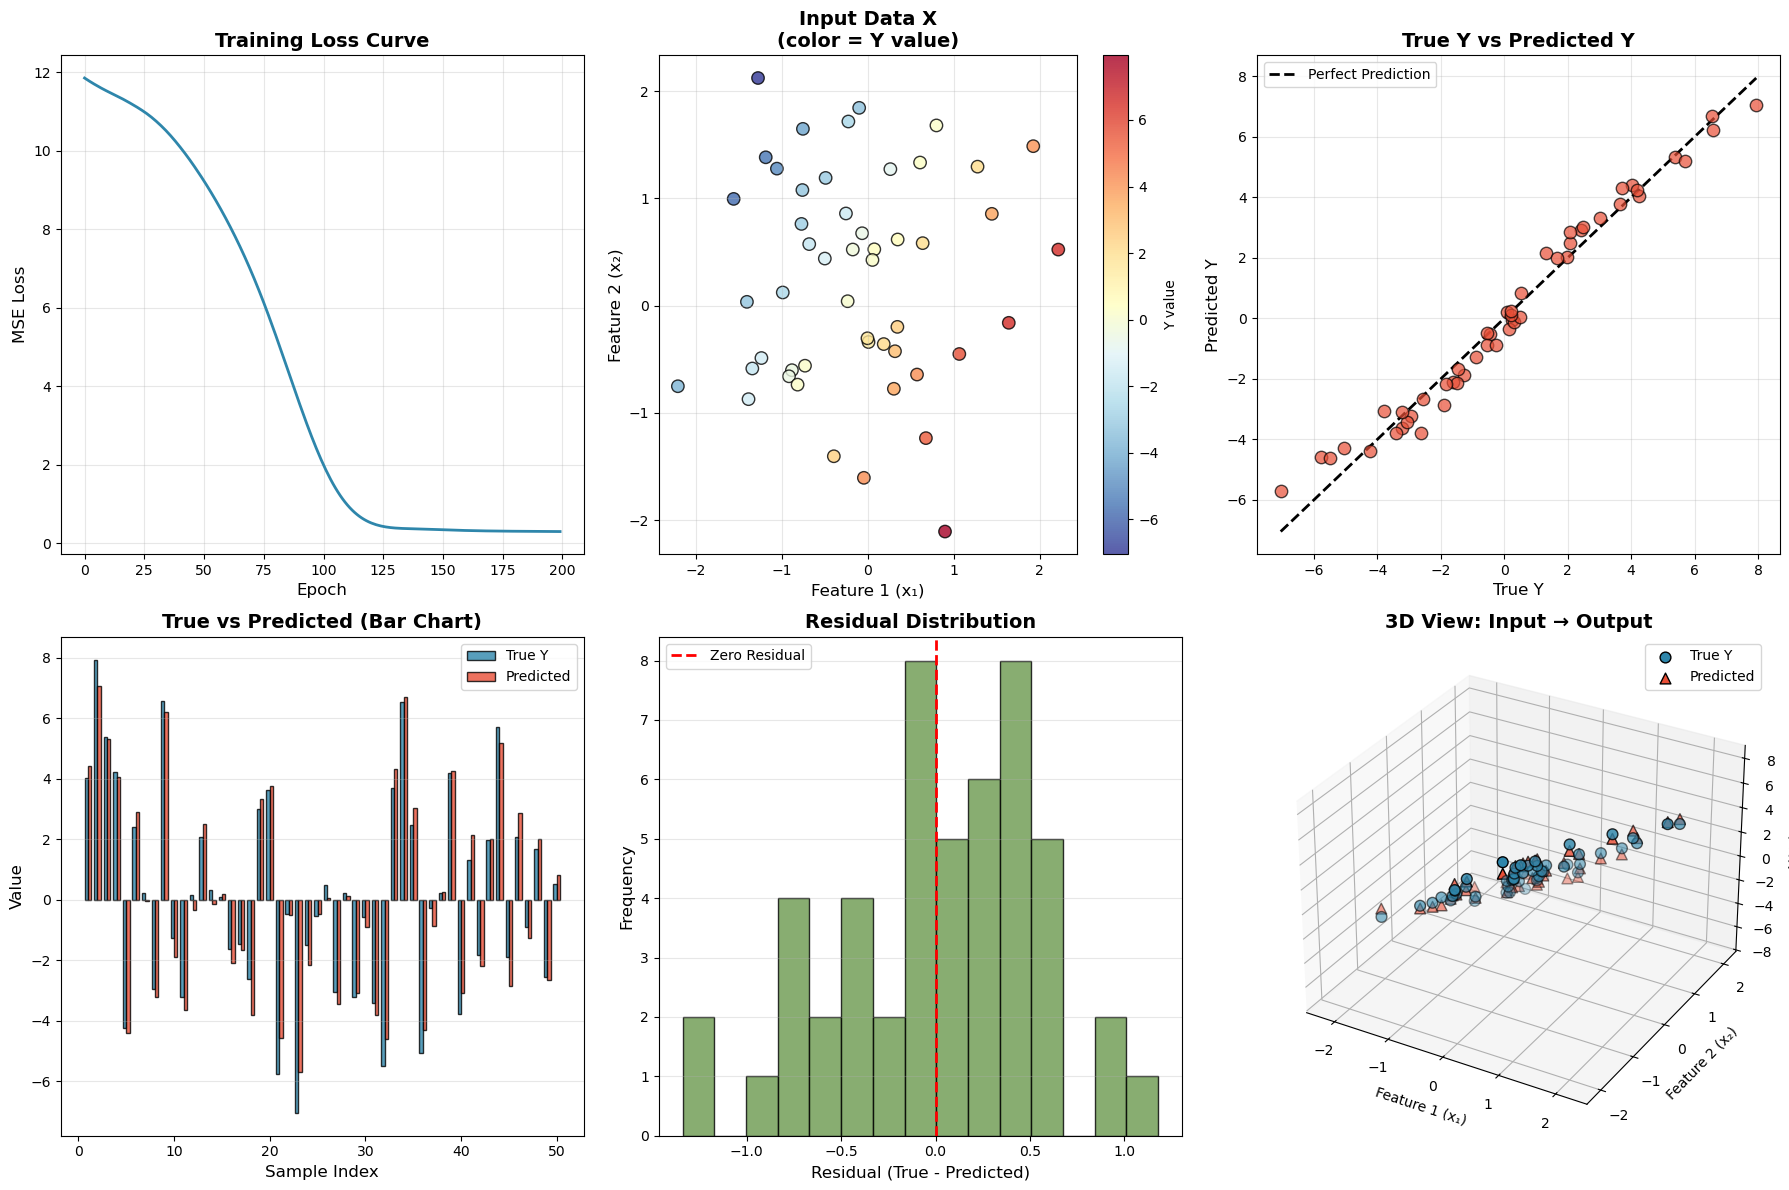

In [13]:

# ==================== 6. 作图 ====================
fig = plt.figure(figsize=(18, 12))

# 子图1：损失曲线
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(loss_history, color='#2E86AB', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MSE Loss', fontsize=12)
ax1.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 子图2：输入特征分布（散点图，颜色表示Y值）
ax2 = fig.add_subplot(2, 3, 2)
scatter = ax2.scatter(X_np[:, 0], X_np[:, 1], c=Y_np.flatten(), 
                       cmap='RdYlBu_r', s=80, edgecolors='black', alpha=0.8)
plt.colorbar(scatter, ax=ax2, label='Y value')
ax2.set_xlabel('Feature 1 (x₁)', fontsize=12)
ax2.set_ylabel('Feature 2 (x₂)', fontsize=12)
ax2.set_title('Input Data X\n(color = Y value)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 子图3：真实值 vs 预测值（散点对比）
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(Y_np, Y_pred, c='#E94F37', s=80, edgecolors='black', alpha=0.7, zorder=3)
min_val = min(Y_np.min(), Y_pred.min())
max_val = max(Y_np.max(), Y_pred.max())
ax3.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
ax3.set_xlabel('True Y', fontsize=12)
ax3.set_ylabel('Predicted Y', fontsize=12)
ax3.set_title('True Y vs Predicted Y', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 子图4：每个样本的真实值与预测值（柱状图）
ax4 = fig.add_subplot(2, 3, 4)
sample_idx = np.arange(1, n_samples + 1)
width = 0.35
ax4.bar(sample_idx - width/2, Y_np.flatten(), width, label='True Y', color='#2E86AB', edgecolor='black', alpha=0.8)
ax4.bar(sample_idx + width/2, Y_pred.flatten(), width, label='Predicted', color='#E94F37', edgecolor='black', alpha=0.8)
ax4.set_xlabel('Sample Index', fontsize=12)
ax4.set_ylabel('Value', fontsize=12)
ax4.set_title('True vs Predicted (Bar Chart)', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 子图5：残差分布
ax5 = fig.add_subplot(2, 3, 5)
residuals = (Y_np - Y_pred).flatten()
ax5.hist(residuals, bins=15, color='#6A994E', edgecolor='black', alpha=0.8)
ax5.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
ax5.set_xlabel('Residual (True - Predicted)', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title('Residual Distribution', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 子图6：3D 可视化
ax6 = fig.add_subplot(2, 3, 6, projection='3d')
ax6.scatter(X_np[:, 0], X_np[:, 1], Y_np.flatten(), c='#2E86AB', s=60, label='True Y', edgecolors='black')
ax6.scatter(X_np[:, 0], X_np[:, 1], Y_pred.flatten(), c='#E94F37', s=60, label='Predicted', edgecolors='black', marker='^')
ax6.set_xlabel('Feature 1 (x₁)', fontsize=10)
ax6.set_ylabel('Feature 2 (x₂)', fontsize=10)
ax6.set_zlabel('Y Value', fontsize=10)
ax6.set_title('3D View: Input → Output', fontsize=14, fontweight='bold')
ax6.legend()

plt.tight_layout()
plt.savefig('simple_nn_training.png', dpi=150, bbox_inches='tight')
plt.show()